In [2]:
import pandas as pd
from pathlib import Path
import pyarrow as pa  # not yet needed, might need it later
import pyarrow.parquet as pq
import pyarrow.compute as pc  # not yet needed, might need it later.
import matplotlib.pyplot as plt
import seaborn as sns
from gen.gen_variable_standard_static import metrics_search_for_two_fragments_df, \
metrics_search_for_fragment_df

In [3]:
metrics_dir = Path('../../data/raw/parquet-metrics/')
# Note: We generally give a directory, rather than an individual file, to the next step.
metrics_pq = pq.ParquetDataset(metrics_dir)
metrics_df = metrics_pq.read().to_pandas()

In [4]:
systems_cleaned = pd.read_csv('../../data/core/systems_cleaned.csv')
all_data_systems = systems_cleaned[
    systems_cleaned['has_current_data']
    & systems_cleaned['has_irradiance_data']
    & systems_cleaned['has_power_data']
    & systems_cleaned['has_temperature_data']
    & systems_cleaned['has_voltage_data']
]
all_data_ids = set(all_data_systems.system_id)

parquet_systems = systems_cleaned.loc[
    systems_cleaned.loc[:, 'is_lake_parquet_data']
]  # is already boolean!
all_parquet_system_ids = list(parquet_systems.system_id.unique())
all_parquet_system_ids.sort()

all_rich_parquet_data_ids = set(all_data_systems.system_id.unique()).intersection(
    set(all_parquet_system_ids)
)
all_rich_parquet_data_ids = list(all_rich_parquet_data_ids)
all_rich_parquet_data_ids.sort()

In [5]:
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'sample_year', 'num_days_actual_records'],
      dtype='str')

In [6]:
systems_cleaned['system_source'].value_counts()

system_source
PV Output        1454
PVDB              240
PVDAQ General     160
Prize               5
Name: count, dtype: int64

In [7]:
systems_cleaned[systems_cleaned['system_id']==10000]

,system_id,system_public_name,site_location,timezone_or_utc_offset,latitude,longitude,elevation_m,dc_capacity_kW,kg_climate,pvcz_composite,...,has_power_data,has_current_data,has_voltage_data,has_ac_data,has_dc_data,module_type,simplified_type,system_source,sample_year,num_days_actual_records
163,10000,Pvoutput.org Erics System,ZIP: 55116,America/Chicago,44.914573,-93.162525,288.79187,5.85,Dfa,33,...,True,False,False,True,False,multi-Si,multicrystalline_Si,PV Output,0,0


In [8]:
systems_cleaned.columns

Index(['system_id', 'system_public_name', 'site_location',
       'timezone_or_utc_offset', 'latitude', 'longitude', 'elevation_m',
       'dc_capacity_kW', 'kg_climate', 'pvcz_composite', 'pvcz_t_rack',
       'pvcz_t_roof', 'pvcz_humidity', 'pvcz_wind', 'tracking', 'type',
       'azimuth', 'tilt', 'first_timestamp', 'last_timestamp', 'years',
       'number_records', 'dataset_size_mb', 'available_sensor_channels',
       'qa_status', 'qa_issue', 'first_year', 'is_prize_data',
       'is_lake_parquet_data', 'is_lake_csv_data', 'has_irradiance_data',
       'has_ambient_temperature_data', 'has_temperature_data',
       'has_power_data', 'has_current_data', 'has_voltage_data', 'has_ac_data',
       'has_dc_data', 'module_type', 'simplified_type', 'system_source',
       'sample_year', 'num_days_actual_records'],
      dtype='str')

<Axes: xlabel='num_days_actual_records'>

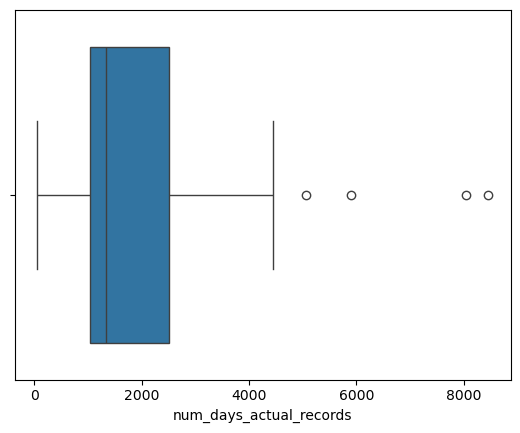

In [ ]:
sns.boxplot(data=systems_cleaned[systems_cleaned['has_power_data']
                                 & systems_cleaned['is_lake_parquet_data']
                                 & (systems_cleaned['num_days_actual_records'] > 2)],
            x = 'num_days_actual_records')

In [ ]:
metrics_search_for_two_fragments_df(
    metrics_df, 'err', 'fault', 'or'
)

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
101,1201,2798,inverter_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inverter_error_code__2798
164,1203,2900,inv1_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inv1_error_code__2900
165,1203,2907,inv2_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inv2_error_code__2907
458,1276,3032,inverter_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inverter_error_code__3032
473,1277,3047,inverter_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inverter_error_code__3047
498,1278,3062,inv1_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inv1_error_code__3062
499,1278,3071,inv2_error_code,System status,-,-,1.0,0.0,,union,NaN,NaN,,inv2_error_code__3071
562,1294,5,error,System status,-,-,1.0,0.0,,union,NaN,NaN,,error__5
567,1295,10,error,System status,-,-,1.0,0.0,,union,NaN,NaN,,error__10
572,1296,15,error,System status,-,-,1.0,0.0,,union,NaN,NaN,,error__15


In [ ]:
metrics_search_for_two_fragments_df(
    metrics_df, 'err', 'fault', 'or'
).system_id.count()

np.int64(43)

In [ ]:
systems_cleaned.columns[-1]

'num_days_actual_records'

<Axes: xlabel='num_days_actual_records', ylabel='Count'>

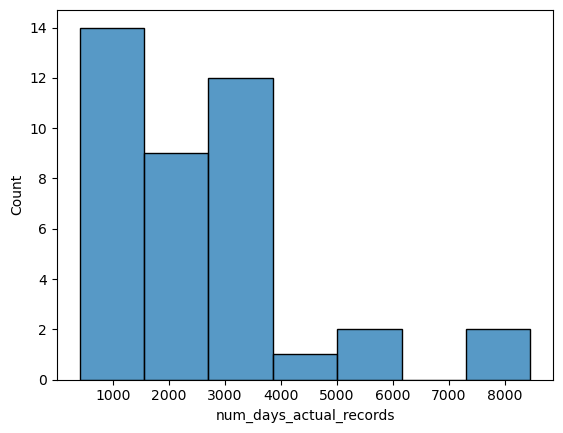

In [ ]:
sns.histplot(
    data = systems_cleaned[systems_cleaned['system_id'].isin(all_rich_parquet_data_ids)],
    x = 'num_days_actual_records'
)

In [ ]:
j = 8
system_id = all_rich_parquet_data_ids[j]
relevant_rows_metrics = metrics_df[metrics_df['system_id'] == system_id]
relevant_rows_metrics

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1726,50,751,dc_power,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power__751
1727,50,752,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__752
1728,50,765,dc_power_1,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power_1__765
1729,50,766,dc_power_2,DC power,W,W,1.0,0.0,,avg,NaN,NaN,,dc_power_2__766
1730,50,767,ac_power_1,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power_1__767
1731,50,768,ac_power_2,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power_2__768
1732,50,758,ac_current,AC current,A,A,1.0,0.0,,avg,NaN,NaN,,ac_current__758
1733,50,757,ac_volts,AC voltage,V,V,1.0,0.0,,avg,NaN,NaN,,ac_volts__757
1734,50,754,dc_pos_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,dc_pos_current__754
1735,50,756,dc_neg_current,DC current,A,A,1.0,0.0,,avg,NaN,NaN,,dc_neg_current__756


In [9]:
energy_metrics = metrics_search_for_fragment_df(metrics_df, 'energy')
energy_metric_ids = set(energy_metrics.system_id)
len(energy_metric_ids)

66

In [17]:
metrics_search_for_two_fragments_df(
    relevant_rows_metrics, 'ac', 'pow', 'and'
)

,system_id,metric_id,sensor_name,common_name,raw_units,units,calc_scale,calc_offset,calc_details,aggregation_type,source_type,source_id,comments,standard_name
1727,50,752,ac_power,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power__752
1730,50,767,ac_power_1,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power_1__767
1731,50,768,ac_power_2,AC power,W,W,1.0,0.0,,avg,NaN,NaN,,ac_power_2__768


In [6]:
from gen.gen_variable_standard_static import metrics_search_for_fragment_df, metrics_search_for_two_fragments_df
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#for 'filtered' mode, add 'measured_on' to sensor_names you want.
# for test, intentionally loading in a weird order to experiment.
col_names = ['ac_power', 'ac_power_1', 'ac_power_2']
col_names.insert(0, 'measured_on')
# for old access, access by metric_id.
my_metric_ids = [752, 767, 768]

In [8]:
source = 'filtered'  # 'raw', 'filtered', 'samples', or 'input'
if source == 'filtered':
    access_system_dir = Path(f'../../../data_ds_project/filtered/systems/parquet/{system_id}/')
    current_pq = pq.ParquetDataset(access_system_dir)
    current_df = current_pq.read(columns=col_names).to_pandas()
elif source == 'raw':  # raw data download from all_parquet_downloader
    access_system_dir = Path(f'../../../data_ds_project/systems/parquet/{system_id}/')
    current_pq = pq.ParquetDataset(access_system_dir,
                               filters= [
                                   ('metric_id', 'in', my_metric_ids) #in particular, only look a the my_metric_id's
                               ])
    current_df = current_pq.read().to_pandas()
elif source == 'samples':  # sample data in GitHub
    access_system_dir = Path(f'../../data/sorted_by_metric/systems/parquet/{system_id}/')
    current_pq = pq.ParquetDataset(access_system_dir,
                               filters= [
                                   ('metric_id', 'in', my_metric_ids) #in particular, only look a the my_metric_id's
                               ])
    current_df = current_pq.read().to_pandas()
else: 
    raise ValueError('Not a valid input!')

ArrowInvalid: No match for FieldRef.Name(ac_power_1) in measured_on: timestamp[ns]
poa_irradiance: double
dc_power: double
ac_power: double
dc_pos_voltage: double
dc_pos_current: double
dc_neg_voltage: double
dc_neg_current: double
ac_volts: double
ac_current: double
ambient_temp: double
module_temp_1: double
module_temp_2: double
module_temp_3: double
inveter_temp: double
dc_power_1: double
dc_power_2: double
inverter_temp_2: double
year: dictionary<values=int32, indices=int32, ordered=0>
__fragment_index: int32
__batch_index: int32
__last_in_fragment: bool
__filename: string

In [21]:
access_system_dir = Path(f'../../../data_ds_project/filtered/systems/parquet/50/')
current_pq = pq.ParquetDataset(access_system_dir)
current_df = current_pq.read().to_pandas()

In [23]:
current_df.columns

Index(['measured_on', 'poa_irradiance', 'dc_power', 'ac_power',
       'dc_pos_voltage', 'dc_pos_current', 'dc_neg_voltage', 'dc_neg_current',
       'ac_volts', 'ac_current', 'ambient_temp', 'module_temp_1',
       'module_temp_2', 'module_temp_3', 'inveter_temp', 'dc_power_1',
       'dc_power_2', 'inverter_temp_2', 'year'],
      dtype='str', name='')

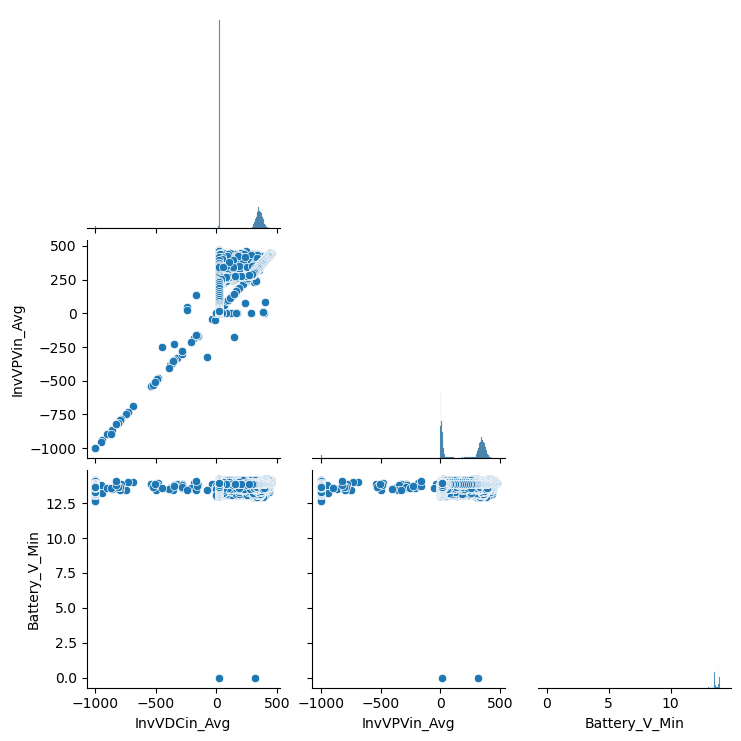

In [21]:
sns.pairplot(
    data=current_df,
    vars = ['InvVDCin_Avg', 'InvVPVin_Avg', 'Battery_V_Min'],
    corner=True
)
plt.show()

Ok, so the order of loading in the argument allows you to sort columns as you please.

In [15]:
current_df_trimmed = current_df[
    (current_df['InvVDCin_Avg'] > 20)
    & (current_df['InvVPVin_Avg'] > 20)
]

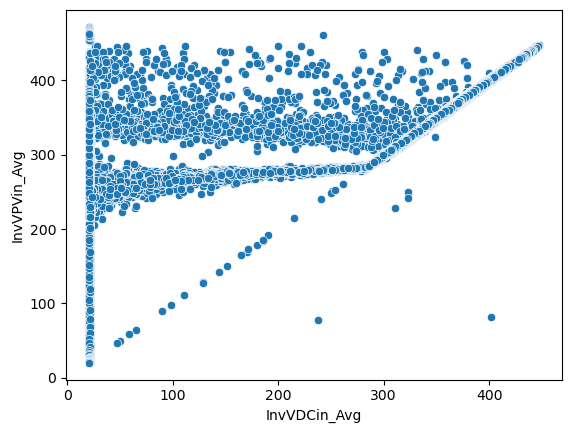

In [16]:
sns.scatterplot(
    data=current_df_trimmed,
    x = 'InvVDCin_Avg',
    y = 'InvVPVin_Avg',
)
plt.show()

In [22]:
current_df_trimmed[['InvVDCin_Avg', 'InvVPVin_Avg']].describe()

,InvVDCin_Avg,InvVPVin_Avg
count,1.192366e+06,1.192366e+06
mean,2.906265e+02,3.003324e+02
std,1.313465e+02,1.166100e+02
min,2.027000e+01,2.001000e+01
25%,3.173000e+02,3.170000e+02
50%,3.457000e+02,3.445000e+02
75%,3.657000e+02,3.648000e+02
max,4.477000e+02,4.721000e+02
